# Student Performance Indicator

Life Cycle of Machine Learning :

1. Understanding Problem Statement
2. Data Collection
3. Data Checks to perform
4. EDA (Exploratory Data Analysis)
5. Data Preprocessing
6. Model Training
7. Choose Best Model

1) Problem Statement : This Project Understands How the student's performance affected by other Variables such as gender,
race_ethnicity,parental_level_of_education, lunch, test_preparation_course, math_score, reading_score, writing_score.

2) Data Collection : Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetld=74977.

### Importing Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np  
import pandas as pd    
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [3]:
df=pd.read_csv('stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of the dataset

In [5]:
df.shape

(1000, 8)

# Dataset Information

1. gender : sex of students -> (Male/female)
2. race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
3. parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high
school)
4. lunch : having lunch before test (standard or free/reduced)
5. test preparation course : complete or not complete before test
6. math score

7. reading score

8. writing score

#  Data Checks to Perform

## Steps :

1. Check Missing values
2. Check Duplicates

3. Check data type

4. Check the number of unique values of each column
5. Check statistics of data set
6. Check various categories present in the different categorical column

### 3.1 Check Missing Values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the data set

### 3.2 Check Duplicates

In [ ]:
df.duplicated().sum()


np.int64(0)

To Remove duplicates


df.drop_duplicates(inplace=True)


   or

   
df_cleaned=df.drop_duplicates()

### 3.3 Check Data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column



In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insights :

1. From above Statistics, mean for math_score, reading_score, writing_score close to each other - between 66 to 68.
2. standard Deviation is also close to each other - between 14 to 15.
3. Minimum value is 0 for math_score and Maximum Value is 100 for all three.

# Exploring the dataset

In [11]:
print("Categories in 'Gender' Variable:    ",end=" ")
print(df['gender'].unique())
print("Categories in 'race_ethnicity' Variable:    ",end=" ")
print(df['race_ethnicity'].unique())
print("Categories in 'parental_level_of_education' Variable:    ",end=" ")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' Variable:    ",end=" ")
print(df['lunch'].unique())
print("Categories in 'test_preparation_course' Variable:    ",end=" ")
print(df['test_preparation_course'].unique())

Categories in 'Gender' Variable:     ['female' 'male']
Categories in 'race_ethnicity' Variable:     ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' Variable:     ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' Variable:     ['standard' 'free/reduced']
Categories in 'test_preparation_course' Variable:     ['none' 'completed']


In [12]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
Categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print("Numerical Features are {}".format(numerical_features))
print("Categorical Features are {}".format(Categorical_features))

Numerical Features are ['math_score', 'reading_score', 'writing_score']
Categorical Features are ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Adding columns : Total_score and Average_score

In [15]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['Average']=df['total_score']/3

In [16]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


### No.of Students with Full Marks in math_score, reading_score,writing_score .

In [17]:
math_full=df[df['math_score']==100]['Average'].count()
reading_full=df[df['reading_score']==100]['Average'].count()
writing_full=df[df['writing_score']==100]['Average'].count()

print("Number of Students with Full marks in Math_score : {}".format(math_full))
print("Number of Students with Full marks in reading_score : {}".format(reading_full))
print("Number of Students with Full marks in writing_score : {}".format(writing_full))

Number of Students with Full marks in Math_score : 7
Number of Students with Full marks in reading_score : 17
Number of Students with Full marks in writing_score : 14


Data Visualization

4.1.1 Histogram & KDE

<Axes: xlabel='Average', ylabel='Count'>

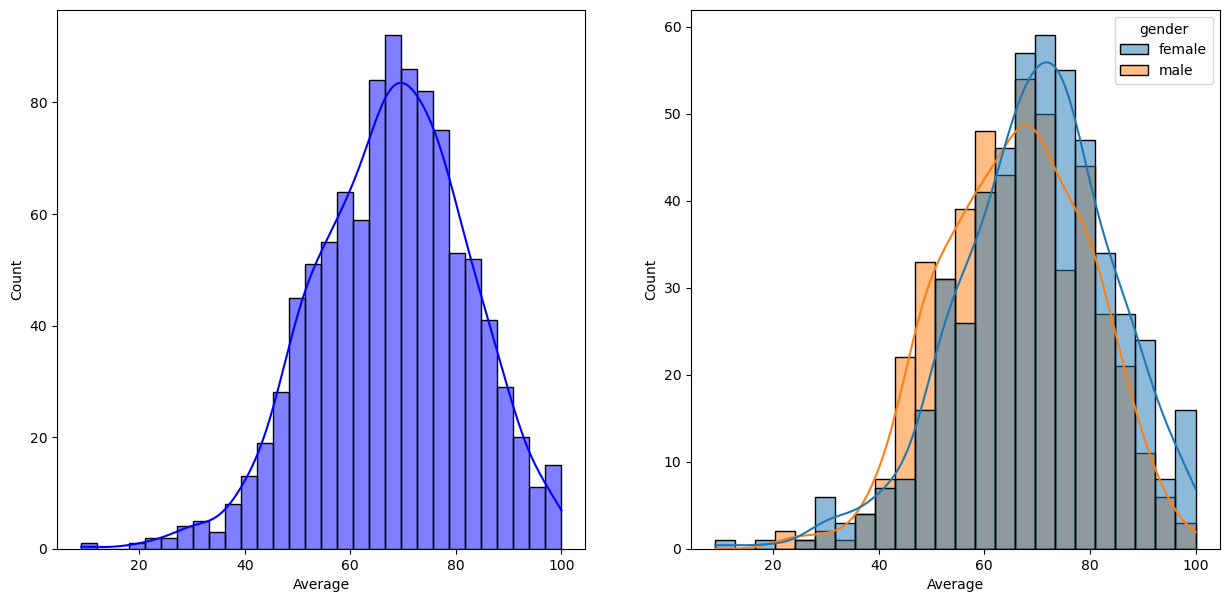

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde=True,hue='gender')

<Axes: xlabel='total_score', ylabel='Count'>

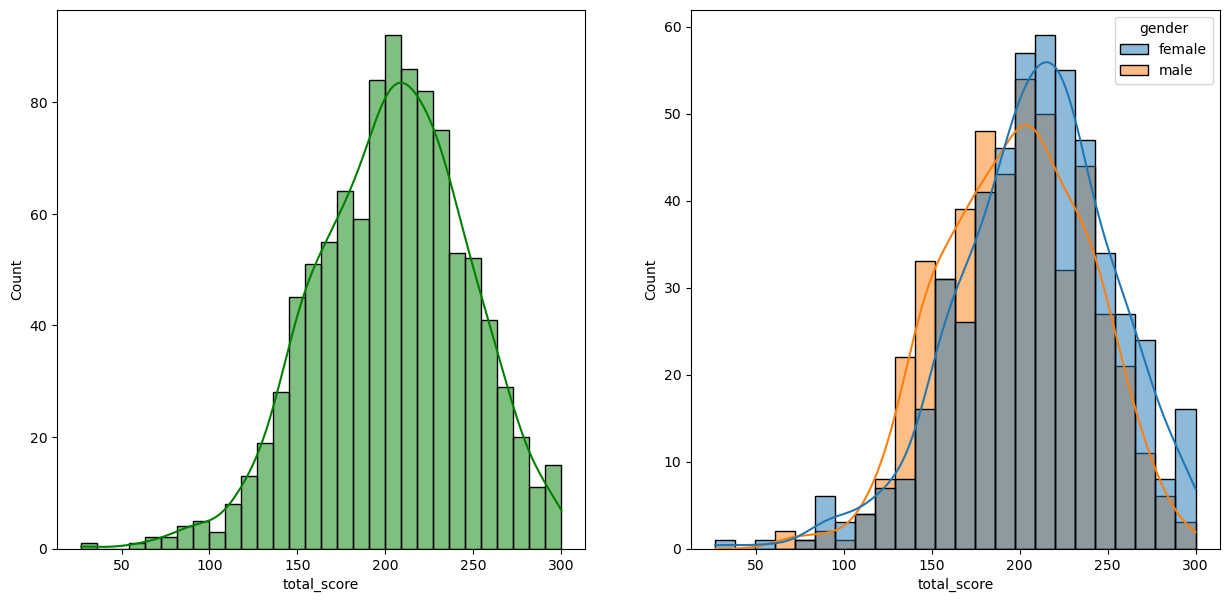

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')

Insights : Female Students perform well in exam then male students.

<Axes: xlabel='Average', ylabel='Count'>

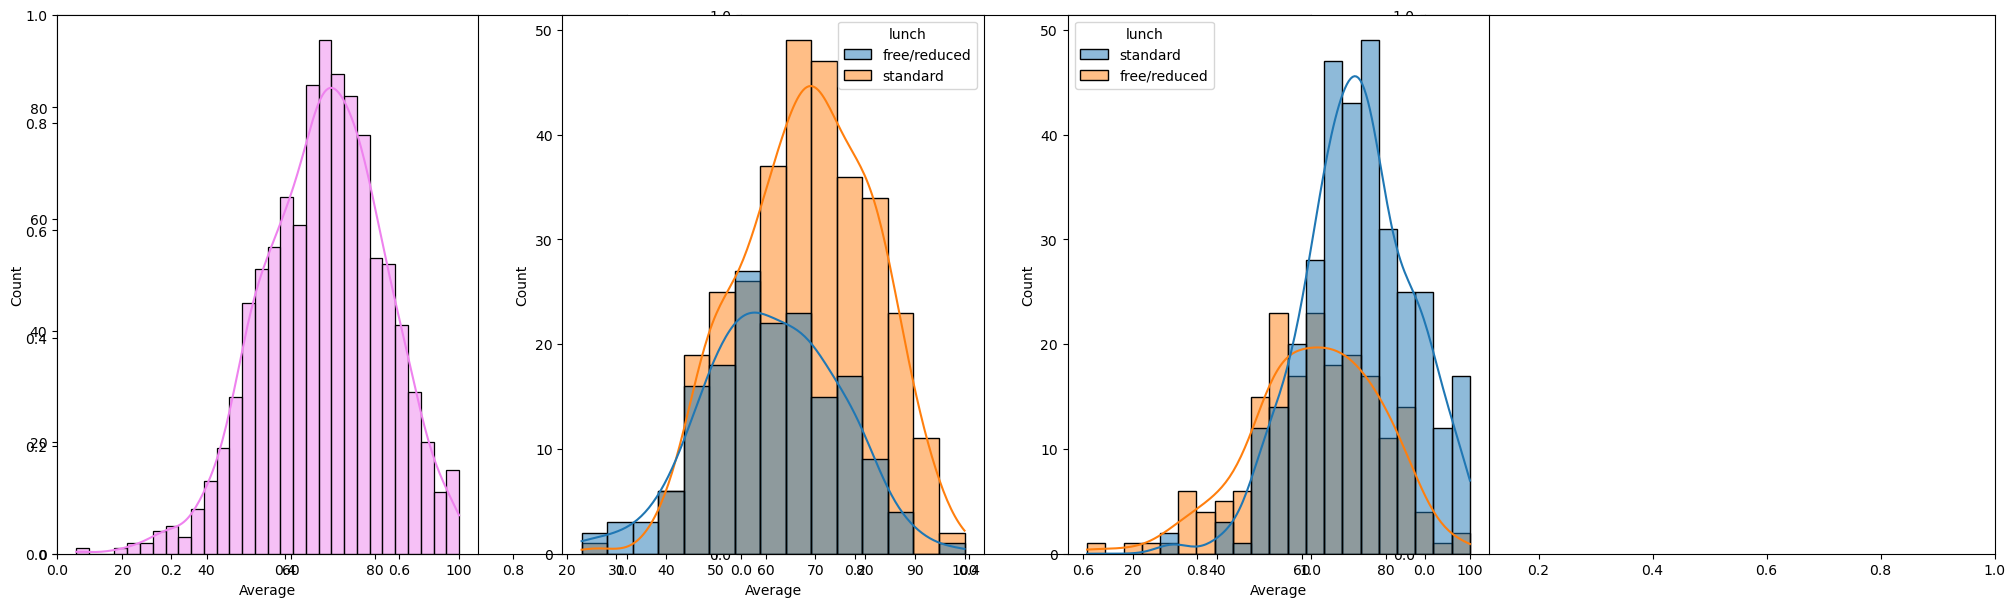

In [20]:
fig, axs=plt.subplots(1,3,figsize=(25,7))
plt.subplot(1,4,1)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='violet')
plt.subplot(1,4,2)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='lunch')
plt.subplot(1,4,3)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='lunch')

Insight :

1. Standard lunch helps to perform well in exams.
2. Standard lunch helps to perform well in exams for both genders (Male and female).

<Axes: xlabel='Average', ylabel='Count'>

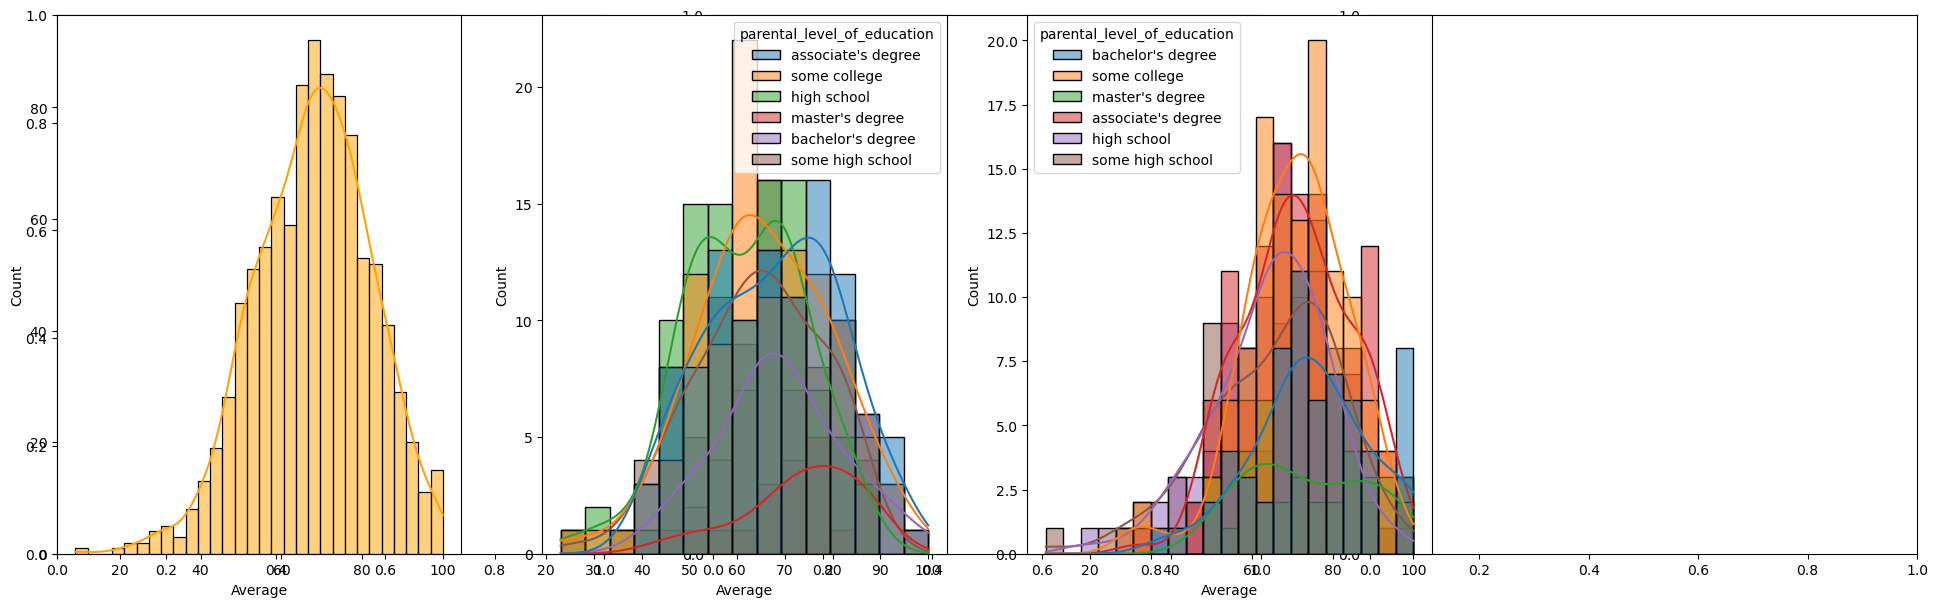

In [21]:
plt.subplots(1,3,figsize=(24,7))
plt.subplot(141)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='orange')
plt.subplot(142)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='parental_level_of_education')

Insights :

1. In general, Parents education dont help student to perform well in exam
2. when you observe in Chart 2, we can say that whose education is of Associate's degree or master's degree their child tend to
perform well in exams.
3. when you observe in chart 3, we can say that for female students has no effect with parental education.

<Axes: xlabel='Average', ylabel='Count'>

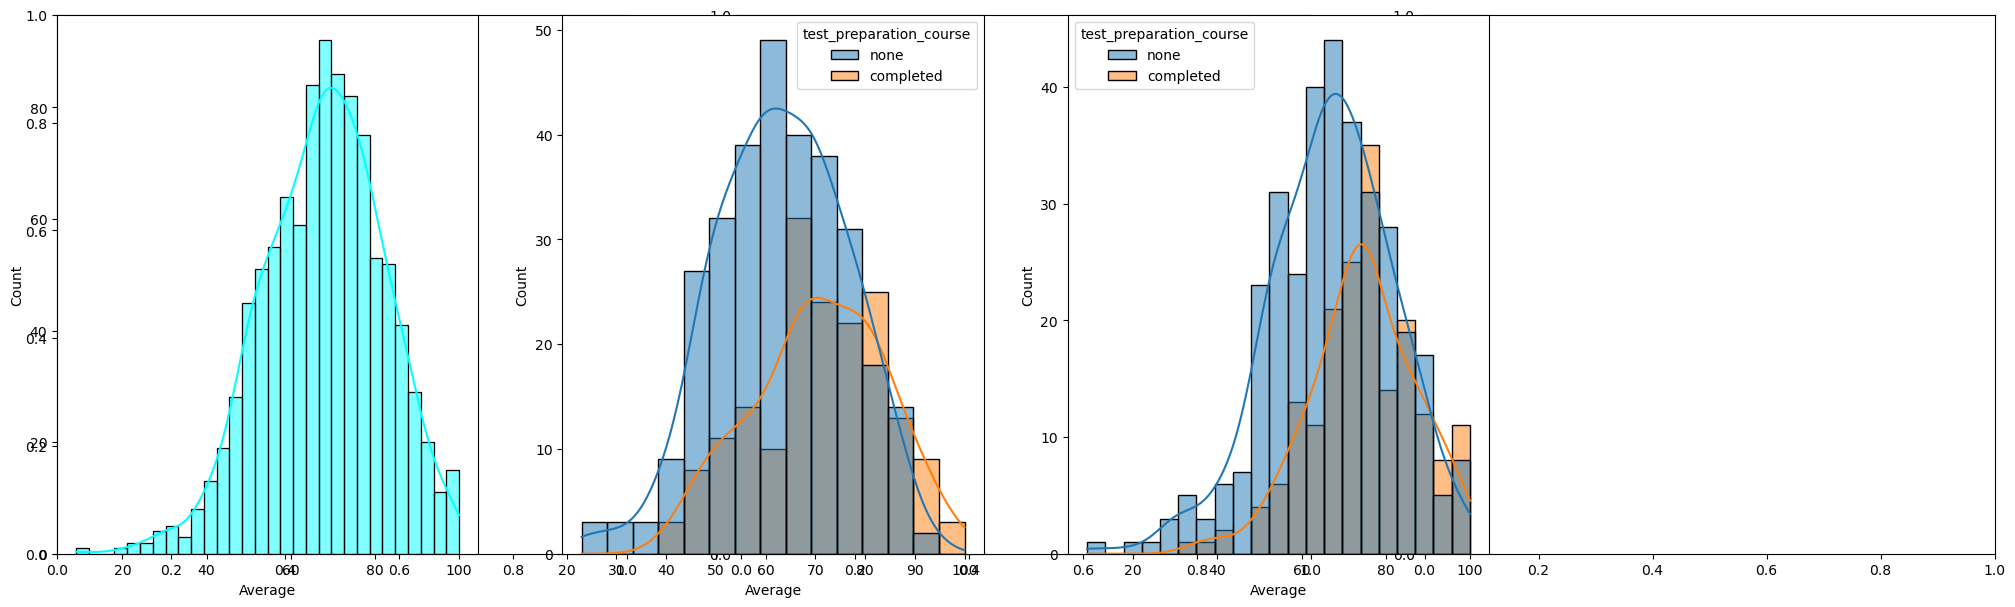

In [22]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(141)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='cyan')
plt.subplot(142)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='test_preparation_course')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='test_preparation_course')

Insight:

1. Students performing well in exam who are all completing the test prepartion course.

<Axes: xlabel='Average', ylabel='Count'>

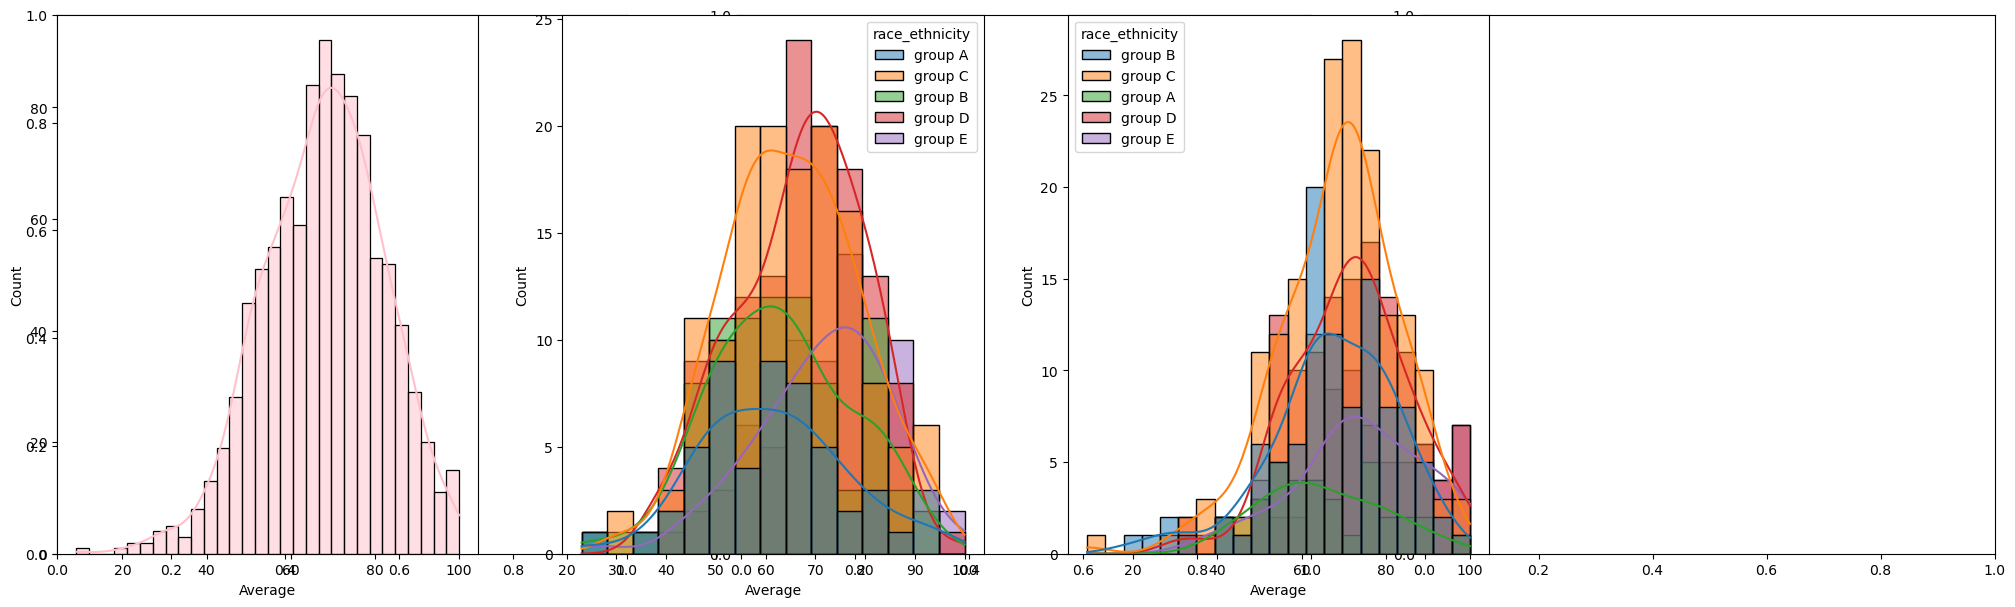

In [23]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(141)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='pink')
plt.subplot(142)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='race_ethnicity')

Insights: Students from Group B and Group C tends to perform poorly in exams.

### Maximum score of students in all three subjects (Math score, Reading score,Writing score)

<Axes: title={'center': 'Writing Score'}, ylabel='writing_score'>

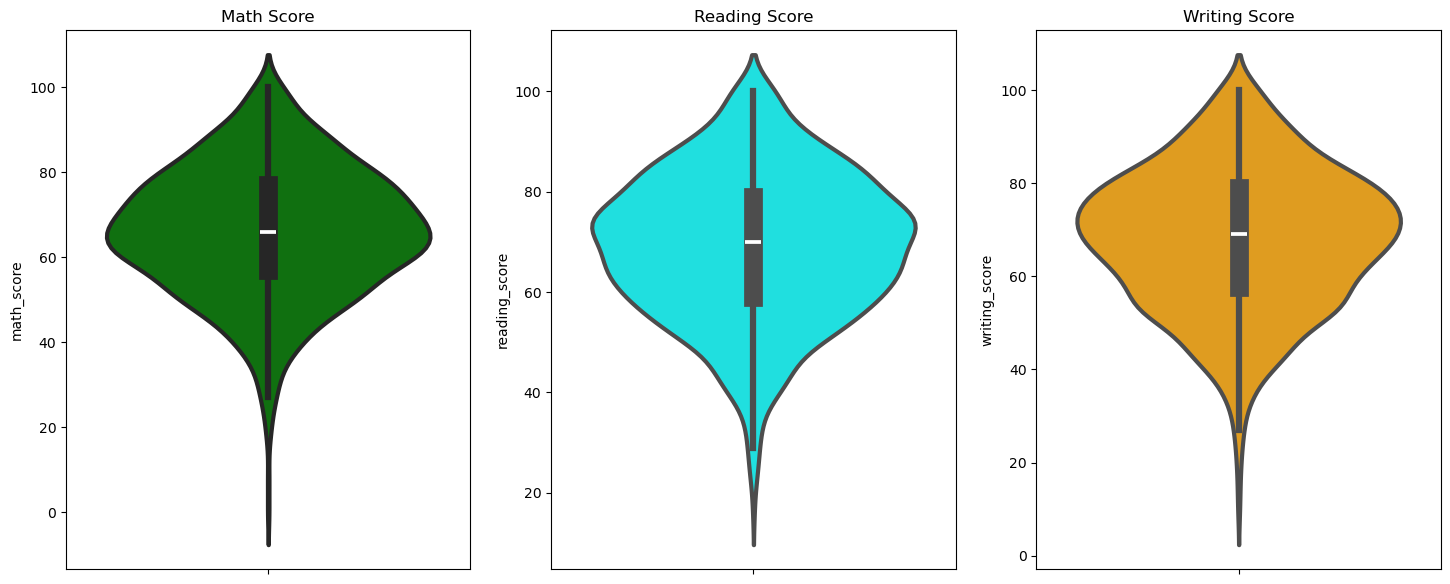

In [24]:
plt.figure(figsize=(24,7))
plt.subplot(141)
plt.title("Math Score")
sns.violinplot(y='math_score',data=df,color='green',linewidth=3)
plt.subplot(142)
plt.title("Reading Score")
sns.violinplot(y='reading_score',data=df,color='cyan',linewidth=3)
plt.subplot(143)
plt.title("Writing Score")
sns.violinplot(y='writing_score',data=df,color='orange',linewidth=3)

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

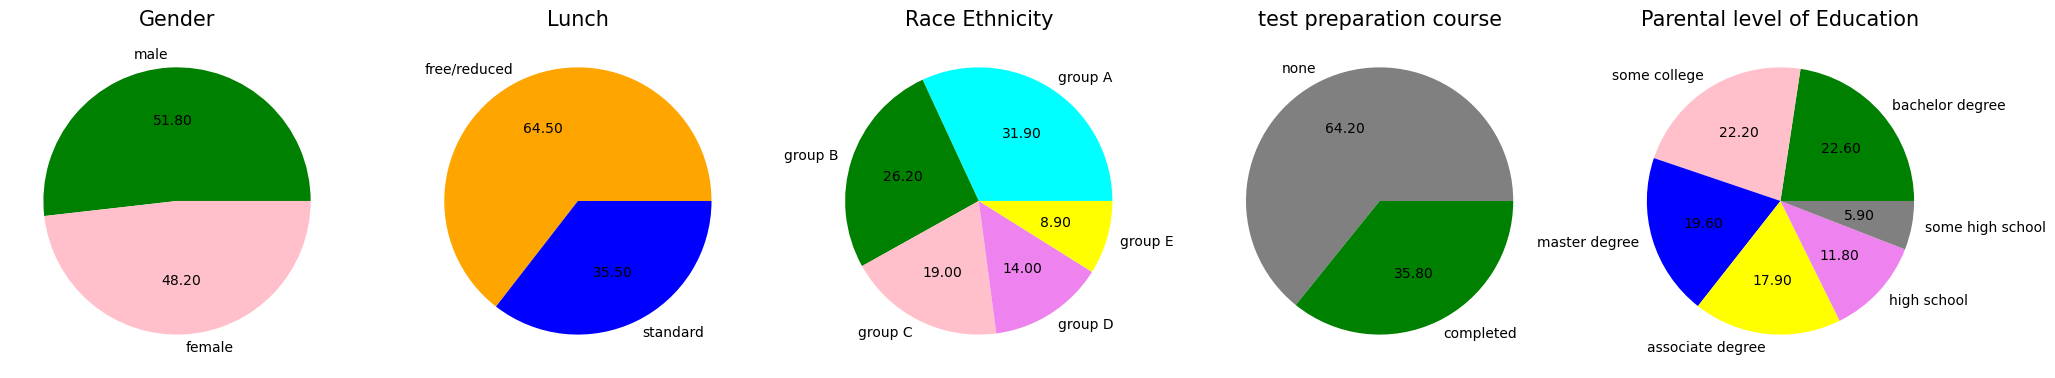

In [25]:
plt.rcParams['figure.figsize']=(25,12)

plt.subplot(151)
size=df['gender'].value_counts()
labels=['male','female']
colors=['green','pink']

plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Gender',fontsize=15)
plt.axis('off')

plt.subplot(152)
size=df['lunch'].value_counts()
labels=['free/reduced','standard']
colors=['orange','blue']

plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Lunch',fontsize=15)
plt.axis('off')

plt.subplot(153)
size=df['race_ethnicity'].value_counts()
labels=['group A','group B','group C','group D','group E']
colors=['cyan','green','pink','violet','yellow']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Race Ethnicity',fontsize=15)
plt.axis('off')


plt.subplot(154)
size=df['test_preparation_course'].value_counts()
labels=['none','completed']
colors=['grey','green']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('test preparation course',fontsize=15)
plt.axis('off')


plt.subplot(155)
size=df['parental_level_of_education'].value_counts()
labels=['bachelor degree','some college','master degree','associate degree','high school','some high school']
colors=['green','pink','blue','yellow','violet','grey']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Parental level of Education',fontsize=15)
plt.axis('off')

Insights:

1. No.of male and female students are almost equal
2. No.of students who have standard lunch are greater
3. No.of Students are greater in Group B race ethnicity
4. No.of Students who are not enrolled in test preparation course
5. No.of Students whose parental level of education is greater for 'Some college' and followed by 'bachelor degree'

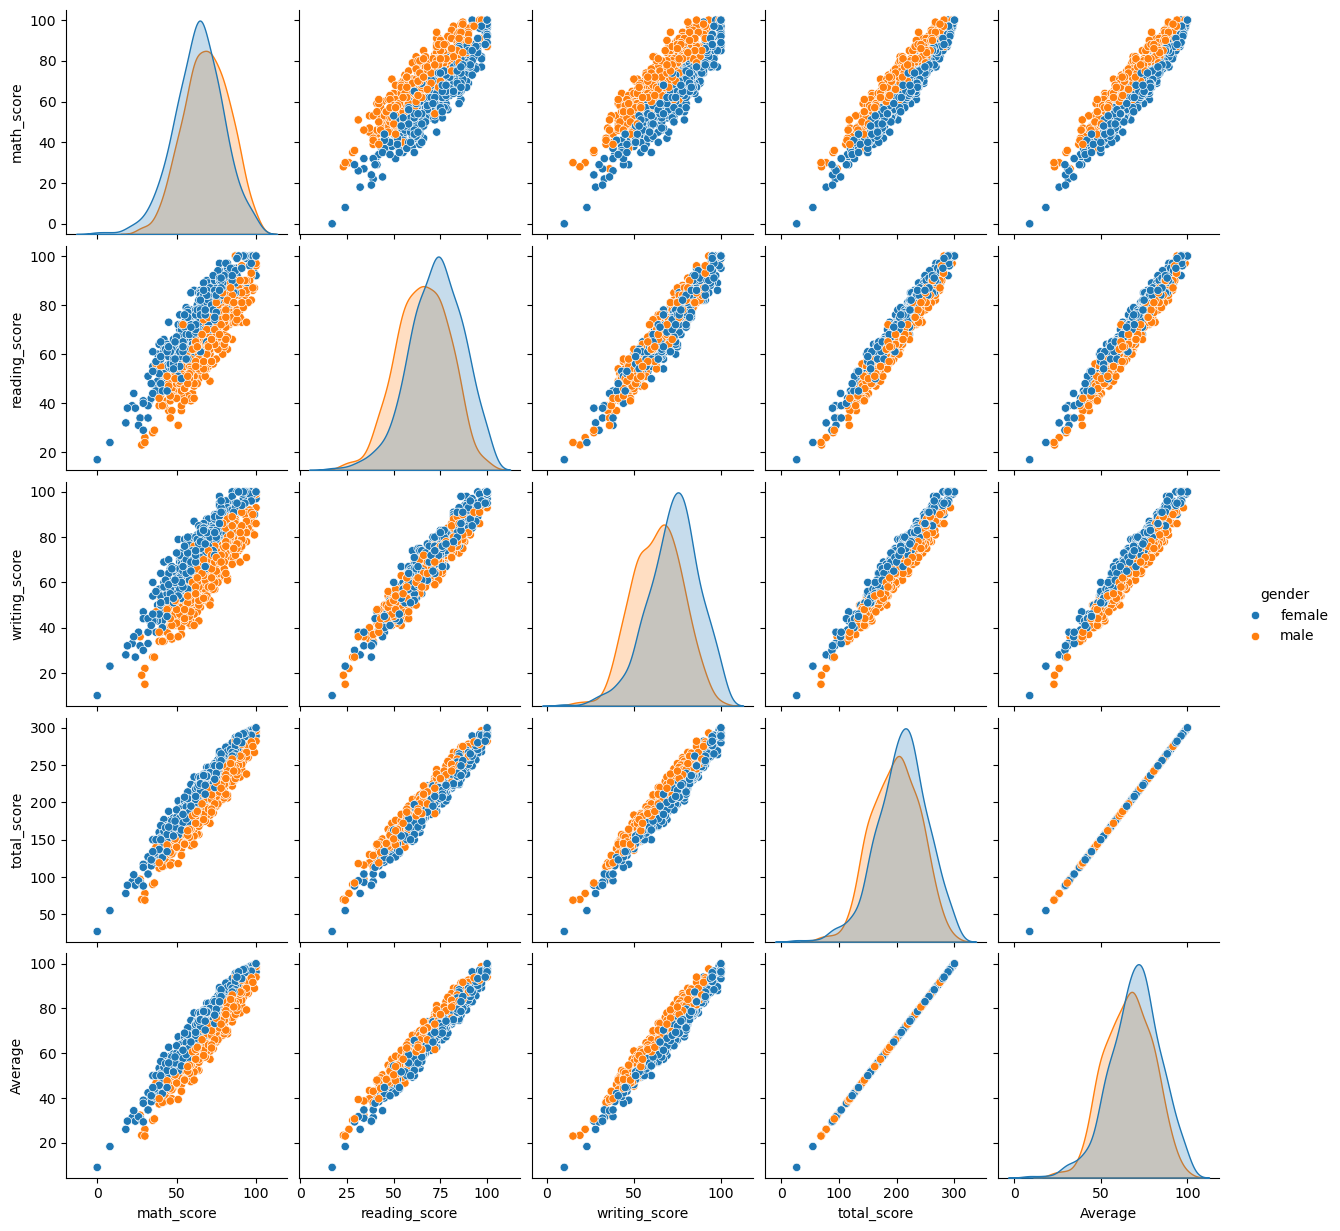

In [26]:
sns.pairplot(df,hue='gender')